SMART HR PROMOTION DASHBOARD - HYBRID SYSTEM
Machine Learning + MCDM (SAW) for Employee Promotion

DATA INGESTION
Shape Train: (54808, 13)
Shape Test : (23490, 12)

Target Distribution (Train):
is_promoted
0    50140
1     4668
Name: count, dtype: int64
Proporsi Promosi: 8.52%

PREPROCESSING - HANDLING MISSING VALUES
Missing values sebelum handling:
  Train: 6533 missing
  Test : 2846 missing
Missing values setelah handling:
  Train: 0 missing
  Test : 0 missing

FEATURE ENGINEERING
New features created:
  - total_training_score
  - experience_ratio
  - rating_award_interaction

ENCODING CATEGORICAL VARIABLES
  Encoded department: {'Analytics': 0, 'Finance': 1, 'HR': 2, 'Legal': 3, 'Operations': 4, 'Procurement': 5, 'R&D': 6, 'Sales & Marketing': 7, 'Technology': 8}
  Encoded education: {"Bachelor's": 0, 'Below Secondary': 1, "Master's & above": 2}
  Encoded gender: {'f': 0, 'm': 1}

Features setelah drop: ['department', 'education', 'gender', 'no_of_trainings', 'age', 'previous_year_r

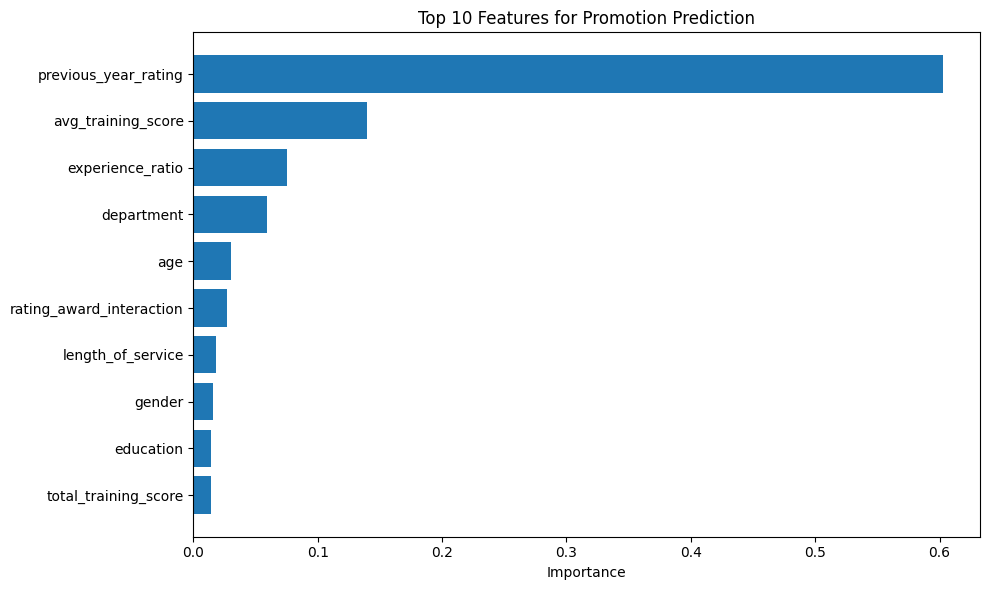


PREDICTING PROMOTION PROBABILITIES

Test Set Results:
  Candidates predicted as promoted: 1667
  Average promotion probability: 0.1997
  Min probability: 0.0037
  Max probability: 0.9958

MCDM - DECISION MATRIX DESIGN (SAW METHOD)

MCDM Criteria and Weights (AHP):
  promotion_prob: 0.35
  previous_year_rating: 0.15
  awards_won?: 0.1
  avg_training_score: 0.1
  length_of_service: 0.2
  no_of_trainings: 0.1

Decision Matrix Shape: (10, 6)
Alternatives: ['Emp_16522', 'Emp_24844', 'Emp_4313', 'Emp_40934', 'Emp_52757', 'Emp_22939', 'Emp_12315', 'Emp_43070', 'Emp_7506', 'Emp_62168']

NORMALIZATION (SAW METHOD)

Normalized Decision Matrix:
           previous_year_rating  awards_won?  avg_training_score  length_of_service  no_of_trainings  promotion_prob
Emp_16522                   0.8            0              0.8312             0.3889              0.5          0.0843
Emp_24844                   1.0            0              0.7792             0.2778              0.5          0.7687
Emp_43

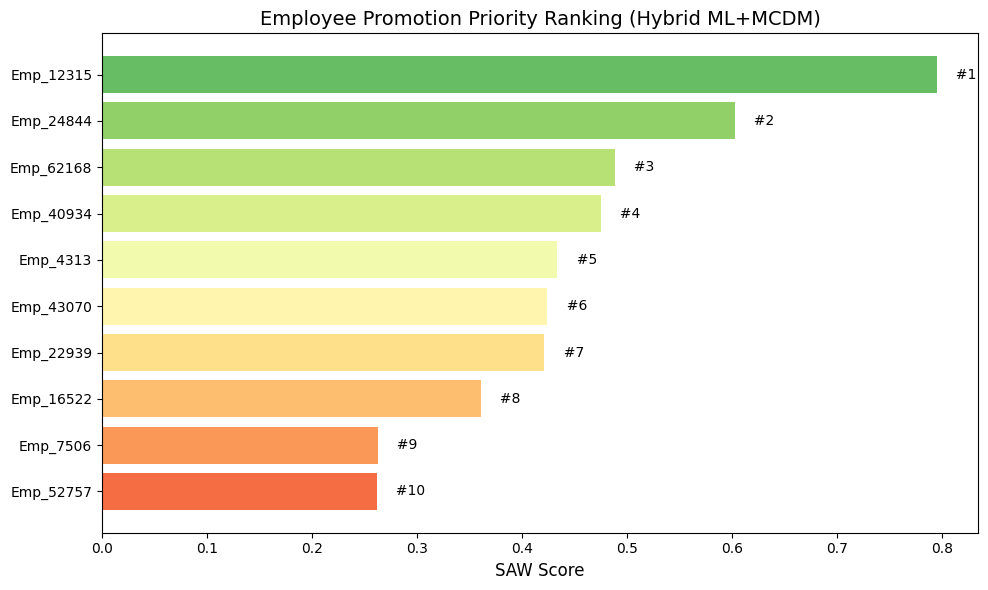


DECISION MATRIX (Original Values)
           previous_year_rating  awards_won?  avg_training_score  length_of_service  no_of_trainings ML_Probability  Promotion_Prob
Emp_16522                   4.0            0                  64                  7                1          5.48%          0.0548
Emp_24844                   5.0            0                  60                  5                1         50.00%          0.5000
Emp_4313                    3.0            0                  48                 10                1         22.31%          0.2231
Emp_40934                   3.0            0                  59                 18                1         10.84%          0.1084
Emp_52757                   3.0            0                  45                  1                1          9.66%          0.0966
Emp_22939                   3.0            0                  49                 12                1         15.64%          0.1564
Emp_12315                   5.0          

In [2]:
# ============================================
# MATERI 5 - KASUS 3: EMPLOYEE PROMOTION
# SISTEM HIBRIDA ML + MCDM (SAW)
# MENGGUNAKAN FILE TRAIN.CSV DAN TEST.CSV ASLI
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE

print("="*70)
print("SMART HR PROMOTION DASHBOARD - HYBRID SYSTEM")
print("Machine Learning + MCDM (SAW) for Employee Promotion")
print("="*70)

# ============================================
# 1. LOAD DATASET
# ============================================
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("\n" + "="*60)
print("DATA INGESTION")
print("="*60)
print(f"Shape Train: {train.shape}")
print(f"Shape Test : {test.shape}")
print(f"\nTarget Distribution (Train):")
print(train['is_promoted'].value_counts())
print(f"Proporsi Promosi: {train['is_promoted'].mean()*100:.2f}%")

# ============================================
# 2. PREPROCESSING - HANDLE MISSING VALUES
# ============================================
print("\n" + "="*60)
print("PREPROCESSING - HANDLING MISSING VALUES")
print("="*60)

# Cek missing values sebelum
print("Missing values sebelum handling:")
print(f"  Train: {train.isnull().sum().sum()} missing")
print(f"  Test : {test.isnull().sum().sum()} missing")

# Handle missing values
train['education'] = train['education'].fillna(train['education'].mode()[0])
train['previous_year_rating'] = train['previous_year_rating'].fillna(train['previous_year_rating'].mode()[0])

test['education'] = test['education'].fillna(test['education'].mode()[0])
test['previous_year_rating'] = test['previous_year_rating'].fillna(test['previous_year_rating'].mode()[0])

print("Missing values setelah handling:")
print(f"  Train: {train.isnull().sum().sum()} missing")
print(f"  Test : {test.isnull().sum().sum()} missing")

# ============================================
# 3. FEATURE ENGINEERING
# ============================================
print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Total training score
train['total_training_score'] = train['avg_training_score'] * train['no_of_trainings']
test['total_training_score'] = test['avg_training_score'] * test['no_of_trainings']

# Rasio pengalaman vs usia
train['experience_ratio'] = train['length_of_service'] / (train['age'] + 1)
test['experience_ratio'] = test['length_of_service'] / (test['age'] + 1)

# Interaksi rating dan penghargaan
train['rating_award_interaction'] = train['previous_year_rating'] * train['awards_won?']
test['rating_award_interaction'] = test['previous_year_rating'] * test['awards_won?']

print("New features created:")
print("  - total_training_score")
print("  - experience_ratio")
print("  - rating_award_interaction")

# ============================================
# 4. ENCODING CATEGORICAL VARIABLES
# ============================================
print("\n" + "="*60)
print("ENCODING CATEGORICAL VARIABLES")
print("="*60)

categorical_cols = ['department', 'education', 'gender']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])
    label_encoders[col] = le
    print(f"  Encoded {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

# ============================================
# 5. DROP UNNECESSARY COLUMNS
# ============================================
cols_to_drop = ['employee_id', 'recruitment_channel', 'region']
train = train.drop([c for c in cols_to_drop if c in train.columns], axis=1)
test = test.drop([c for c in cols_to_drop if c in test.columns], axis=1)

print(f"\nFeatures setelah drop: {train.columns.tolist()}")

# ============================================
# 6. SPLIT DATA UNTUK TRAINING & VALIDATION
# ============================================
X = train.drop('is_promoted', axis=1)
y = train['is_promoted']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nSplit Data:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.value_counts().to_dict()}")
print(f"  X_val: {X_val.shape}, y_val: {y_val.value_counts().to_dict()}")

# ============================================
# 7. HANDLING IMBALANCED DATA dengan SMOTE
# ============================================
print("\n" + "="*60)
print("HANDLING IMBALANCED DATA - SMOTE")
print("="*60)

print(f"Before SMOTE - Class 0: {sum(y_train==0)}, Class 1: {sum(y_train==1)}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"After SMOTE - Class 0: {sum(y_train_resampled==0)}, Class 1: {sum(y_train_resampled==1)}")

# ============================================
# 8. FEATURE SCALING
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(test)

print("\nFeature scaling completed with StandardScaler")

# ============================================
# 9. TRAINING MODEL - GRADIENT BOOSTING
# ============================================
print("\n" + "="*60)
print("TRAINING MODEL - GRADIENT BOOSTING")
print("="*60)

model = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

model.fit(X_train_scaled, y_train_resampled)

# Evaluasi
y_pred = model.predict(X_val_scaled)
y_prob = model.predict_proba(X_val_scaled)[:, 1]

print("\nMODEL EVALUATION ON VALIDATION SET:")
print("="*40)
print(f"Accuracy  : {accuracy_score(y_val, y_pred):.4f}")
print(f"Precision : {precision_score(y_val, y_pred):.4f}")
print(f"Recall    : {recall_score(y_val, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_val, y_prob):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
print(f"\nConfusion Matrix:")
print(f"  TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]}, TP: {cm[1,1]}")

# ============================================
# 10. FEATURE IMPORTANCE
# ============================================
print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

feature_names = X.columns.tolist()
importances = model.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

print("\nTop 10 Features:")
print(fi_df.head(10).to_string(index=False))

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'][:10], fi_df['Importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Features for Promotion Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# ============================================
# 11. PREDIKSI PROBABILITAS UNTUK TEST DATA
# ============================================
print("\n" + "="*60)
print("PREDICTING PROMOTION PROBABILITIES")
print("="*60)

# Prediksi probabilitas untuk test set
test_probabilities = model.predict_proba(X_test_scaled)[:, 1]
test_predictions = (test_probabilities >= 0.5).astype(int)

print(f"\nTest Set Results:")
print(f"  Candidates predicted as promoted: {sum(test_predictions)}")
print(f"  Average promotion probability: {test_probabilities.mean():.4f}")
print(f"  Min probability: {test_probabilities.min():.4f}")
print(f"  Max probability: {test_probabilities.max():.4f}")

# ============================================
# 12. MCDM - DECISION MATRIX DESIGN
# ============================================
print("\n" + "="*60)
print("MCDM - DECISION MATRIX DESIGN (SAW METHOD)")
print("="*60)

# Ambil sample 10 karyawan dari test set untuk demo
sample_size = min(10, len(test))
sample_indices = np.random.choice(len(test), sample_size, replace=False)

# Ambil data karyawan sample
sample_employees = test.iloc[sample_indices].copy()
sample_probabilities = test_probabilities[sample_indices]
sample_original = pd.read_csv('test.csv').iloc[sample_indices]  # untuk nama karyawan

# Beri nama alternatif
if 'employee_id' in sample_original.columns:
    alternative_names = [f"Emp_{int(eid)}" for eid in sample_original['employee_id']]
else:
    alternative_names = [f"Candidate_{i+1}" for i in range(sample_size)]
sample_employees.index = alternative_names

# Kriteria untuk MCDM
criteria = {
    'promotion_prob': 0.35,      # dari ML (benefit)
    'previous_year_rating': 0.15, # rating kinerja (benefit)
    'awards_won?': 0.10,          # penghargaan (benefit)
    'avg_training_score': 0.10,   # skor pelatihan (benefit)
    'length_of_service': 0.20,    # masa kerja (benefit)
    'no_of_trainings': 0.10       # jumlah pelatihan (benefit)
}

print("\nMCDM Criteria and Weights (AHP):")
for k, v in criteria.items():
    print(f"  {k}: {v}")

# Buat decision matrix
decision_cols = ['previous_year_rating', 'awards_won?', 'avg_training_score', 
                  'length_of_service', 'no_of_trainings']
decision_matrix = sample_employees[decision_cols].copy()
decision_matrix['promotion_prob'] = sample_probabilities

print(f"\nDecision Matrix Shape: {decision_matrix.shape}")
print(f"Alternatives: {decision_matrix.index.tolist()}")

# ============================================
# 13. NORMALISASI MATRIKS (SAW)
# ============================================
print("\n" + "="*60)
print("NORMALIZATION (SAW METHOD)")
print("="*60)

# Normalisasi untuk benefit criteria: nilai / max(nilai)
normalized = pd.DataFrame(index=decision_matrix.index)

for col in decision_matrix.columns:
    max_val = decision_matrix[col].max()
    if max_val > 0:
        normalized[col] = decision_matrix[col] / max_val
    else:
        normalized[col] = decision_matrix[col]

print("\nNormalized Decision Matrix:")
print(normalized.round(4).to_string())

# ============================================
# 14. PERHITUNGAN SKOR SAW DAN RANKING
# ============================================
print("\n" + "="*60)
print("SAW SCORES AND RANKING")
print("="*60)

# Hitung skor akhir
scores = {}
for alt in normalized.index:
    total = 0
    for col in normalized.columns:
        weight = criteria.get(col, 0)
        total += weight * normalized.loc[alt, col]
    scores[alt] = total

# Buat ranking
ranking_df = pd.DataFrame({
    'Alternative': list(scores.keys()),
    'Score': list(scores.values())
}).sort_values('Score', ascending=False)

ranking_df['Rank'] = range(1, len(ranking_df) + 1)

print("\nFINAL RANKING - PROMOTION PRIORITY:")
print("="*50)
for _, row in ranking_df.iterrows():
    prob = sample_probabilities[alternative_names.index(row['Alternative'])]
    print(f"  Rank {int(row['Rank'])}: {row['Alternative']}")
    print(f"       Score: {row['Score']:.4f} | ML Probability: {prob:.2%}")

# ============================================
# 15. VISUALISASI RANKING
# ============================================
plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(ranking_df)))
bars = plt.barh(ranking_df['Alternative'], ranking_df['Score'], color=colors)
plt.xlabel('SAW Score', fontsize=12)
plt.title('Employee Promotion Priority Ranking (Hybrid ML+MCDM)', fontsize=14)
plt.gca().invert_yaxis()

# Tambahkan label rank
for i, (_, row) in enumerate(ranking_df.iterrows()):
    plt.text(row['Score'] + 0.01, i, f"  #{int(row['Rank'])}", va='center')

plt.tight_layout()
plt.savefig('promotion_ranking.png', dpi=150)
plt.show()

# ============================================
# 16. DECISION MATRIX (ORIGINAL VALUES)
# ============================================
print("\n" + "="*60)
print("DECISION MATRIX (Original Values)")
print("="*60)

display_df = decision_matrix.copy()
display_df['ML_Probability'] = display_df['promotion_prob'].apply(lambda x: f"{x:.2%}")
display_df['Promotion_Prob'] = display_df['promotion_prob'].round(4)
display_df = display_df.drop('promotion_prob', axis=1)
print(display_df.to_string())

# ============================================
# 17. WHAT-IF ANALYSIS - SCENARIO SIMULATION
# ============================================
print("\n" + "="*60)
print("WHAT-IF ANALYSIS: TRAINING INTERVENTION")
print("="*60)

# Pilih karyawan dengan skor terendah
lowest_rank = ranking_df.iloc[-1]['Alternative']
lowest_idx = alternative_names.index(lowest_rank)

print(f"Intervensi pada karyawan: {lowest_rank}")
print(f"  Current avg_training_score: {sample_employees.loc[lowest_rank, 'avg_training_score']}")
print(f"  Current no_of_trainings: {sample_employees.loc[lowest_rank, 'no_of_trainings']}")

# Simulasi intervensi
modified_employees = sample_employees.copy()
modified_employees.loc[lowest_rank, 'avg_training_score'] = 95
modified_employees.loc[lowest_rank, 'no_of_trainings'] = 8

# Hitung ulang probabilitas ML
modified_features = modified_employees[decision_cols].copy()
# Scaling untuk prediksi ulang
modified_scaled = scaler.transform(modified_employees[X.columns.intersection(modified_employees.columns)])
modified_probs = model.predict_proba(modified_scaled)[:, 1]

# Decision matrix baru
new_decision_matrix = modified_employees[decision_cols].copy()
new_decision_matrix['promotion_prob'] = modified_probs

# Normalisasi ulang
new_normalized = pd.DataFrame(index=new_decision_matrix.index)
for col in new_decision_matrix.columns:
    max_val = new_decision_matrix[col].max()
    if max_val > 0:
        new_normalized[col] = new_decision_matrix[col] / max_val
    else:
        new_normalized[col] = new_decision_matrix[col]

# Hitung skor baru
new_scores = {}
for alt in new_normalized.index:
    total = 0
    for col in new_normalized.columns:
        weight = criteria.get(col, 0)
        total += weight * new_normalized.loc[alt, col]
    new_scores[alt] = total

new_ranking = pd.DataFrame({
    'Alternative': list(new_scores.keys()),
    'Score': list(new_scores.values())
}).sort_values('Score', ascending=False)
new_ranking['Rank'] = range(1, len(new_ranking) + 1)

# Bandingkan ranking
print("\n" + "="*60)
print("WHAT-IF RESULT - RANKING COMPARISON")
print("="*60)

comparison = ranking_df.set_index('Alternative').join(
    new_ranking.set_index('Alternative'), rsuffix='_new'
)
comparison['Rank_Change'] = comparison['Rank'] - comparison['Rank_new']
print(comparison[['Rank', 'Rank_new', 'Rank_Change', 'Score', 'Score_new']].to_string())

# ============================================
# 18. WHAT-IF SCENARIO 2: AWARD RECOGNITION
# ============================================
print("\n" + "="*60)
print("WHAT-IF ANALYSIS: AWARD RECOGNITION")
print("="*60)

# Pilih karyawan dengan performa bagus tapi belum dapat award
candidates = ranking_df[ranking_df['Alternative'].isin(alternative_names)]
for _, row in candidates.iterrows():
    alt = row['Alternative']
    if sample_employees.loc[alt, 'awards_won?'] == 0 and sample_employees.loc[alt, 'previous_year_rating'] >= 3.5:
        award_candidate = alt
        break
else:
    award_candidate = ranking_df.iloc[1]['Alternative']

print(f"Memberikan penghargaan kepada: {award_candidate}")
print(f"  Current previous_year_rating: {sample_employees.loc[award_candidate, 'previous_year_rating']}")

# Simulasi
modified_employees2 = sample_employees.copy()
modified_employees2.loc[award_candidate, 'awards_won?'] = 1
modified_employees2.loc[award_candidate, 'previous_year_rating'] = min(5, sample_employees.loc[award_candidate, 'previous_year_rating'] + 0.5)

# Hitung ulang
modified_scaled2 = scaler.transform(modified_employees2[X.columns.intersection(modified_employees2.columns)])
modified_probs2 = model.predict_proba(modified_scaled2)[:, 1]

new_decision_matrix2 = modified_employees2[decision_cols].copy()
new_decision_matrix2['promotion_prob'] = modified_probs2

new_normalized2 = pd.DataFrame(index=new_decision_matrix2.index)
for col in new_decision_matrix2.columns:
    max_val = new_decision_matrix2[col].max()
    if max_val > 0:
        new_normalized2[col] = new_decision_matrix2[col] / max_val
    else:
        new_normalized2[col] = new_decision_matrix2[col]

new_scores2 = {}
for alt in new_normalized2.index:
    total = 0
    for col in new_normalized2.columns:
        weight = criteria.get(col, 0)
        total += weight * new_normalized2.loc[alt, col]
    new_scores2[alt] = total

new_ranking2 = pd.DataFrame({
    'Alternative': list(new_scores2.keys()),
    'Score': list(new_scores2.values())
}).sort_values('Score', ascending=False)
new_ranking2['Rank'] = range(1, len(new_ranking2) + 1)

comparison2 = ranking_df.set_index('Alternative').join(
    new_ranking2.set_index('Alternative'), rsuffix='_new'
)
comparison2['Rank_Change'] = comparison2['Rank'] - comparison2['Rank_new']
print("\nRanking Change After Award Recognition:")
print(comparison2[['Rank', 'Rank_new', 'Rank_Change']].head(5).to_string())

# ============================================
# 19. SAVE RESULTS
# ============================================
print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

# Save submission
submission = pd.DataFrame({
    'employee_id': pd.read_csv('test.csv')['employee_id'],
    'is_promoted': test_predictions,
    'promotion_probability': test_probabilities
})
submission.to_csv('submission_hybrid.csv', index=False)
print("Saved: submission_hybrid.csv")

# Save ranking
ranking_df.to_csv('promotion_ranking.csv', index=False)
print("Saved: promotion_ranking.csv")

# Save decision matrix
decision_matrix.to_csv('decision_matrix.csv')
print("Saved: decision_matrix.csv")

print("\n" + "="*70)
print("SIMULATION COMPLETE")
print("="*70)
print("\nSUMMARY:")
print(f"  1. ML Model Recall: {recall_score(y_val, y_pred):.4f}")
print(f"  2. Total candidates evaluated: {len(test)}")
print(f"  3. Candidates recommended for promotion: {sum(test_predictions)}")
print(f"  4. Top ranked candidate: {ranking_df.iloc[0]['Alternative']} (Score: {ranking_df.iloc[0]['Score']:.4f})")
print("\nHybrid System berhasil mengintegrasikan:")
print("  - Machine Learning untuk prediksi probabilitas promosi")
print("  - MCDM (SAW) untuk perankingan multi-kriteria")
print("  - What-If analysis untuk simulasi kebijakan")